# Prescribed terminus advance at EKaS

This notebook guides the Figure 13 comparison. Core model code is in `src/`.
The historical EKaS simulations require regional inputs; the executed examples
below are explicitly labeled synthetic checks. The AGENTS.md and academic style guide are copied exactly from OMP-OOI.
Figure settings reuse its analysis rcParams block; it has no standalone plotting style file.

Dachauer et al. (2026), https://doi.org/10.1017/jog.2026.10172.
The main observable is advance minus fixed-front change in flux and thickness
at a gate 1 km upstream of the 1953 front. Spatial differences complement it.

In [1]:
from pathlib import Path
import sys
root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
sys.path.insert(0, str(root))
import os
os.chdir(root)
import numpy as np
import matplotlib.pyplot as plt
from src.terminus import chronology
from src.plotting import terminus_panel, comparison
print("Repository:", root)
print("Year and approximate advance offset (m):")
print(np.column_stack(chronology()))

Repository: /home/wdiens/notebooks/Icepack-Sediment
Year and approximate advance offset (m):
[[1953.    0.]
 [1985.  960.]
 [2007. 1400.]
 [2021. 1820.]]


## Geometry, stress balance and forcing

The paper's initialized 2021 geometry is truncated to the 1953 front, then held
there for 25 model years. This is not an observed 1953 surface reconstruction.
Both simulations use the same spinup and the same frozen MAR 2021 SMB field.
Read `data/README.md` before selecting the corridor and preparing regional data.

`IceStream` solves SSA using a mixed Coulomb–Weertman sliding potential. The
pressure is overburden minus ocean hydrostatic pressure at the ice base, bounded
at zero. Thickness evolves on a changing corridor mesh with conservative nodal
transfer and velocity relative to mesh motion. A/C inversion, full basin geometry
and the author's corrected bed are not reproduced here.

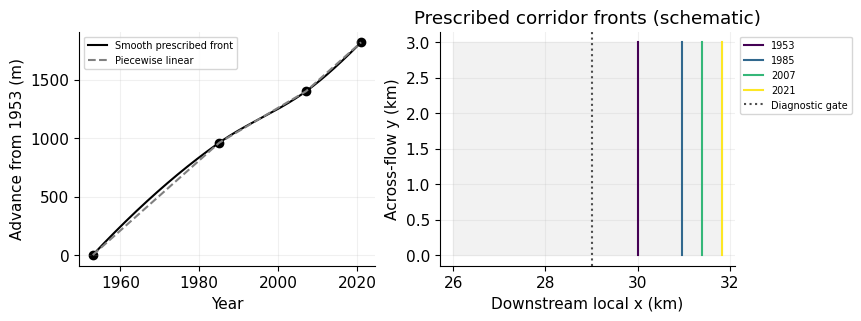

In [2]:
fig = terminus_panel()
plt.show()

## Run the regional experiments

Run these commands from the repository root in a Firedrake/Icepack environment:

```bash
python scripts/prepare_inputs.py data/raw/manifest.json
python scripts/run_fixed_front.py
python scripts/run_advancing_front.py
python scripts/validate_results.py
```

Adjust mesh spacing and timestep in `config.json`; repeat at half timestep and
half spacing to assess convergence. Histories and snapshots remain outside git.
The exact historical front offsets are editable in `data/terminus.csv`.

In [3]:
import json
print(json.dumps(json.loads(Path("config.json").read_text()), indent=2))
regional = all((Path("results") / label / "metadata.json").exists()
               for label in ["fixed_front", "advancing_front"])
print("Regional simulations available:", regional)

{
  "length_1953_m": 30000,
  "width_m": 3000,
  "nx": 120,
  "ny": 12,
  "dt_years": 0.05,
  "spinup_years": 25,
  "end_year": 2021,
  "fluidity": 10,
  "mu": 0.5,
  "side_friction": 0.01,
  "smooth_front": true,
  "quadrature_degree": 2
}
Regional simulations available: False


## Figure 13 comparison

This cell plots saved historical runs when available. Missing runs remain missing;
no paper curves or surrogate values are inserted. The plot includes prescribed
advance rate, gate flux and thickness changes, and advance minus control. A
second figure maps thickness and speed change over the shared initial domain.

In [4]:
if regional:
    comparison("results/fixed_front", "results/advancing_front", "results/figures")
    plt.show()
else:
    print("Historical EKaS Figure 13 comparison has not been run.")
    print("Prepare the regional inputs and execute both experiments to populate it.")

Historical EKaS Figure 13 comparison has not been run.
Prepare the regional inputs and execute both experiments to populate it.


## Executed synthetic solver validation

The short smoke experiments check solver execution, equal initialization,
prescribed front motion, positive thickness and discrete mass balance. They do
not validate the long historical response or agreement with the published glacier.
See `docs/results.pdf` for measured check results and limitations.

smoke_fixed minimum thickness (m): 456.0820038480168 final front offset (m): 0.0 maximum relative mass residual: 9.493202559080048e-17
smoke_advancing minimum thickness (m): 455.7989841672288 final front offset (m): 7.178233358739817 maximum relative mass residual: 9.493202559080048e-17


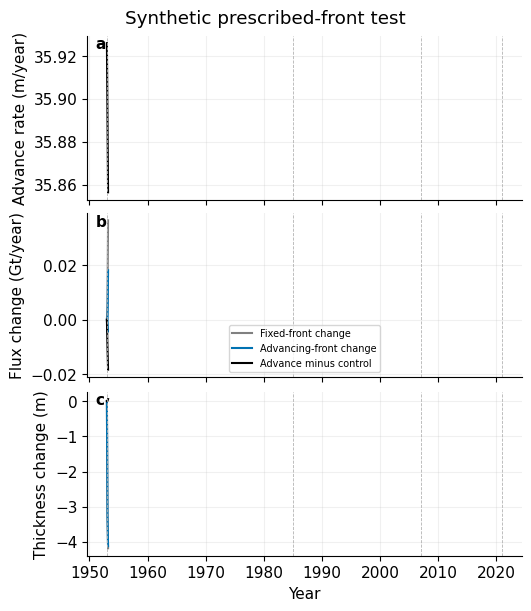

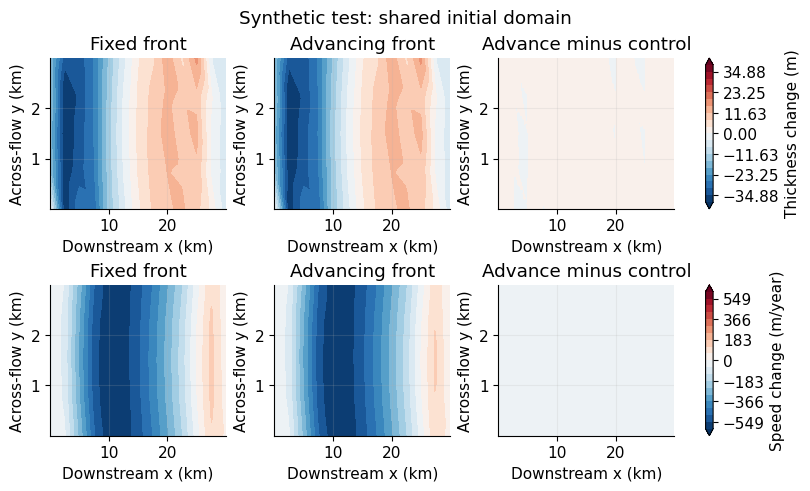

In [5]:
smoke = [Path("results/smoke_fixed"), Path("results/smoke_advancing")]
if all((p / "history.csv").exists() for p in smoke):
    for p in smoke:
        h = np.genfromtxt(p / "history.csv", delimiter=",", names=True)
        print(p.name, "minimum thickness (m):", h["min_h"].min(),
              "final front offset (m):", h["front_m"][-1],
              "maximum relative mass residual:",
              np.max(np.abs(h["mass_residual_m3"][:-1]) / h["volume_m3"][:-1]))
    comparison(*[str(p) for p in smoke], "results/smoke_figures", smoke=True)
    plt.show()
else:
    print("Synthetic results unavailable in this checkout; run the README smoke commands.")

## Longer numerical checks and regional geometry problems

The extended cases use the same synthetic inputs, a 25-year relaxation and the
full 1953–2021 front chronology. They remain synthetic experiments. A one-year
timestep triggered the nonpositive-thickness guard during spinup; a quarter-year
retry tests whether that failure is timestep-dependent. The report records
completed runs and failed attempts separately.

The regional geometry probe uses cached BedMachine v6 and a 2023 flowline. Its
approximate straight-corridor footprint includes ice-free land and zero thickness.
It does not delineate a historical domain or supply MAR 2021 forcing.

{
  "date": "2026-10-08",
  "repository_visibility": "public",
  "template_status": "Exact AGENTS.md and academic guide copied; OMP-OOI rcParams block reused",
  "unit_tests": "5 passed in ekas-figure; map lacks rasterio",
  "firedrake_checks": "CG1 interpolation, mass-conserving transfer and 16 traction-derivative cases passed",
  "regional_geometry": {
    "status": "geometry probe only; not prepared model input",
    "bedmachine": "/home/wdiens/notebooks/EKaS-Sediment-Stability/data/bedmachine/BedMachineGreenland-v6.nc",
    "flowline_sha256": "f9986787fe84830f72c46b394f889b4ac3f5e2bbb16e3e92ecafd3e126b9e39b",
    "assumption": "Modern flowline minus 2 km fjord extension and 1820 m approximate advance",
    "length_1953_m": 30000,
    "width_m": 3000,
    "origin_easting": -20927.304247307966,
    "origin_northing": -3149642.1125321374,
    "downstream_azimuth_deg_from_east": -140.93406589539416,
    "initial_nonice_fraction": 0.2594171997157072,
    "initial_nonpositive_thickness_f

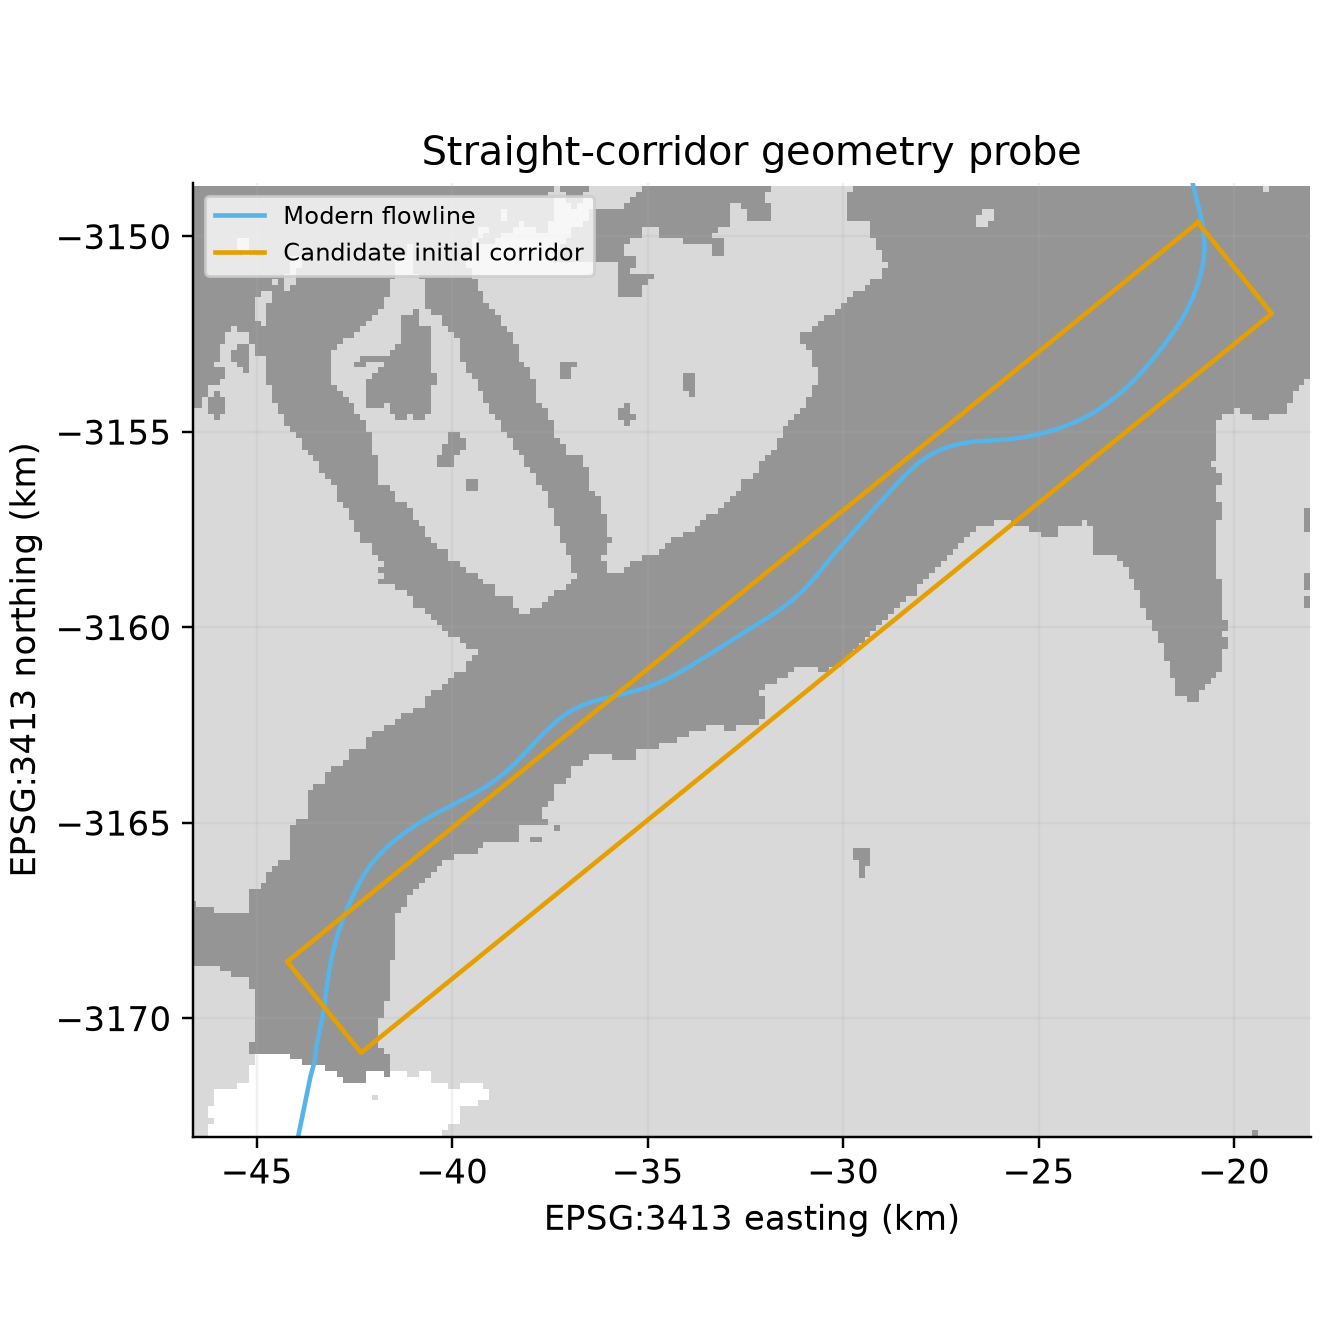

In [6]:
import json
checks = Path("docs/run_checks.json")
if checks.exists():
    print(json.dumps(json.loads(checks.read_text()), indent=2))
from IPython.display import Image, display
print("Candidate corridor check (geometry only):")
print(json.dumps(json.loads(Path("docs/regional_geometry.json").read_text()), indent=2))
display(Image(filename="docs/figures/candidate_corridor.png"))

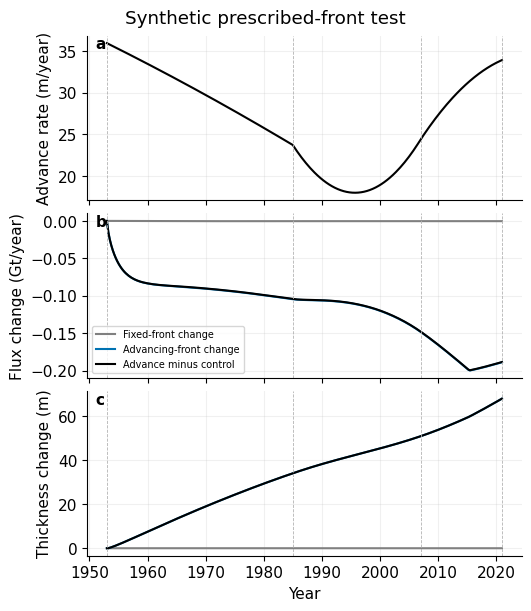

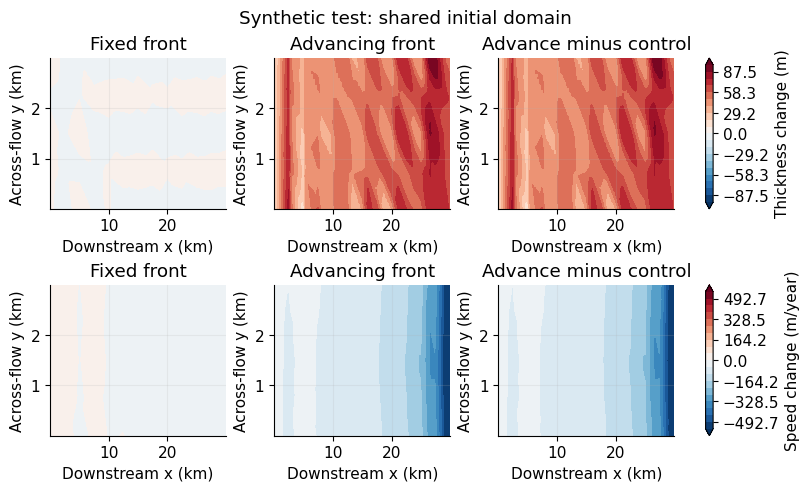

In [7]:
full = [Path("results/synthetic_refined_fixed"), Path("results/synthetic_refined_advancing")]
complete = all((p / "metadata.json").exists() and
               json.loads((p / "metadata.json").read_text())["status"] == "executed"
               for p in full)
if complete:
    comparison(*[str(p) for p in full], "docs/figures/synthetic_full", smoke=True)
    plt.show()
else:
    print("Full synthetic comparison unavailable; see docs/run_checks.json for run status.")

## Interpretation and next step

A complete historical run should be assessed for slowdown and thickening at the
gate relative to control, and spatial concentration near the front. Failure of
that expectation must be reported. Differences could arise from corridor geometry,
friction calibration, bed correction, SMB or numerical convergence. Synthetic
smoke outputs cannot settle that question. Explicit sediment thickness and bank
geometry will follow only after this geometric control experiment is established.